# Évaluation du modèle DQN

Ce notebook évalue les performances du modèle entraîné sur plusieurs épisodes.

In [6]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.envs import LargeTaxiEnv
from src.agent import DQNTaxiAgent
import numpy as np
import matplotlib.pyplot as plt

## 1. Charger le modèle entraîné

In [7]:
env = LargeTaxiEnv(render_mode=None, grid_width=15, grid_height=10, n_passengers=2)
agent = DQNTaxiAgent(env=env)
agent.load("../training/checkpoints/dqn_taxi_final.zip")
print("Modèle chargé !")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[DQN] Modèle chargé ← ../training/checkpoints/dqn_taxi_final.zip
Modèle chargé !


## 2. Évaluer sur N épisodes

In [8]:
def evaluate_agent(agent, env, n_episodes=100):
    """Évalue l'agent sur n_episodes."""
    rewards = []
    steps = []
    successes = 0
    
    for ep in range(n_episodes):
        obs, _ = env.reset()
        total_reward = 0
        step_count = 0
        done = False
        
        while not done:
            action = agent.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            step_count += 1
            done = terminated or truncated
        
        rewards.append(total_reward)
        steps.append(step_count)
        if terminated:  # Succès si tous les passagers livrés
            successes += 1
    
    return {
        "rewards": rewards,
        "steps": steps,
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_steps": np.mean(steps),
        "success_rate": successes / n_episodes * 100,
    }

print("Évaluation en cours...")
metrics = evaluate_agent(agent, env, n_episodes=100)

print("\n" + "="*50)
print("  RÉSULTATS D'ÉVALUATION")
print("="*50)
print(f"  Reward moyen        : {metrics['mean_reward']:.2f} ± {metrics['std_reward']:.2f}")
print(f"  Pas moyens          : {metrics['mean_steps']:.1f}")
print(f"  Taux de succès      : {metrics['success_rate']:.1f}%")
print("="*50)

Évaluation en cours...

  RÉSULTATS D'ÉVALUATION
  Reward moyen        : -500.00 ± 0.00
  Pas moyens          : 500.0
  Taux de succès      : 0.0%


## 3. Visualiser les résultats

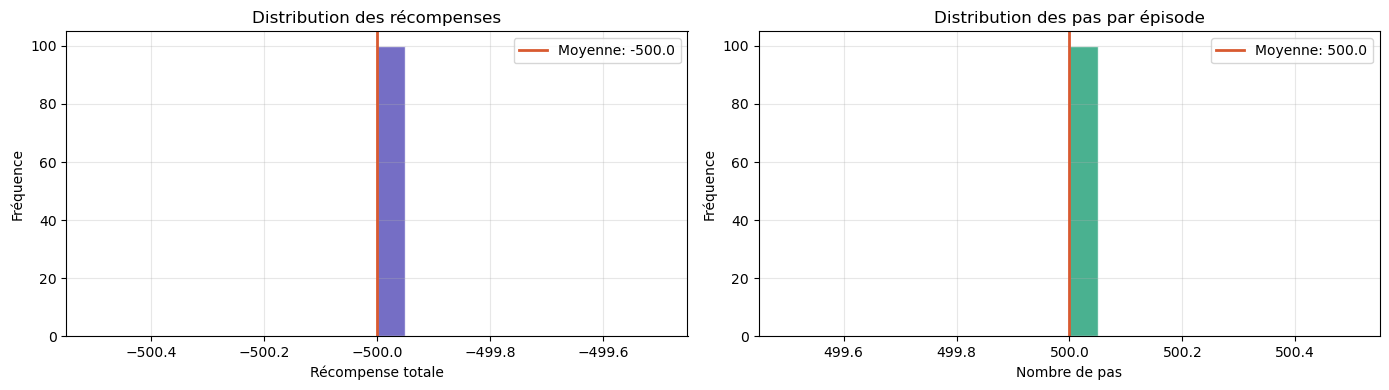

Graphe sauvegardé → ../logs/evaluation_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme des récompenses
axes[0].hist(metrics['rewards'], bins=20, color='#534AB7', edgecolor='white', alpha=0.8)
axes[0].axvline(metrics['mean_reward'], color='#D85A30', linewidth=2, label=f"Moyenne: {metrics['mean_reward']:.1f}")
axes[0].set_xlabel('Récompense totale')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des récompenses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramme des pas
axes[1].hist(metrics['steps'], bins=20, color='#1D9E75', edgecolor='white', alpha=0.8)
axes[1].axvline(metrics['mean_steps'], color='#D85A30', linewidth=2, label=f"Moyenne: {metrics['mean_steps']:.1f}")
axes[1].set_xlabel('Nombre de pas')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des pas par épisode')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/evaluation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Graphe sauvegardé → ../logs/evaluation_distribution.png")

In [10]:
env.close()